Research + Report Agent

EXAMPLE --> "Research future of EV industry in India and save a report" 

Let's make use of these tools for this  -->

1. Planner Node --- this will op in SO
2. Worker Node ----> makes use of WebSearchTool and also, a File Saving tool(need to think more on this)
3. Evaluator Node ----> OP = SO


In [38]:
from typing import Annotated, TypedDict, List, Dict, Any, Optional
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_community.agent_toolkits import PlayWrightBrowserToolkit, FileManagementToolkit
from langchain_community.tools.playwright.utils import create_async_playwright_browser
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from IPython.display import Image, display
import gradio as gr
import uuid
from dotenv import load_dotenv

In [39]:
load_dotenv(override=True)

True

In [40]:
class PlannerSO(BaseModel) : 
    plan : List[str] = Field(description='The plan')

In [41]:
class EvaluatorSO(BaseModel) : 
    feedback : str
    rework_required : bool
    max_retry : int

In [42]:
class State(TypedDict) :
    
    messages : Annotated[List[Any], add_messages]
    plan : List[str]
    feedback : str
    rework_required : bool
    report : str
    max_retry : int

In [59]:
# Get our async Playwright tools
# If you get a NotImplementedError here or later, see the Heads Up at the top of the 3_lab3 notebook

import nest_asyncio
nest_asyncio.apply()
async_browser =  create_async_playwright_browser(headless=False)  # headful mode
toolkit = PlayWrightBrowserToolkit.from_browser(async_browser=async_browser)
web_tools = toolkit.get_tools()



In [60]:
w_tools = web_tools 


In [ ]:
planner_llm = ChatOpenAI(model='gpt-4o-mini')
planner_llm = planner_llm.with_structured_output(PlannerSO)

worker_llm =  ChatOpenAI(model='gpt-4o-mini')
worker_llm_with_tools = worker_llm.bind_tools(w_tools)

evaluator_llm = ChatOpenAI(model='gpt-4o-mini')
evaluator_llm = evaluator_llm.with_structured_output(EvaluatorSO)

In [46]:
def planner(state : State) -> Dict[str, Any] :
    planner_prompt = f''' You are an excellent planner and expert. 
    You are an expert in planning. 
    You are provided with a user's query which is \n {state['messages']}
    Your job is to create a clear step-by-step execution plan
    for solving the user's request.
    Create a concise actionable plan.
    Each step should represent one meaningful action.
    Do not execute the steps.
    Only create the plan.
    '''

    response = planner_llm.invoke(planner_prompt)
    print(f'Planners PLAN - {response}' )

    return {
        'plan' : response
    }


In [90]:
def worker(state : State) -> Dict[str, Any]:

    worker_prompt = f'''
    You are an expert at research.  
    YOu are provided with a plan of action which is \n {state["plan"]}.
    You are also provided with tools such as the Web Search Tool
    for doing the research.
    Use these tools to do research .
    Do not explain what you will do.
    Execute the task using tools and come up with a final report.
    '''

    if state.get('rework_required') :
        worker_prompt += f''' Earlier you had provided the report but it was rejected by the 
        evaluator llm with this feedback -  \n {state["feedback"]}
        With this feedback, please continue the assignment and make it right.                               
    '''

    w_response = worker_llm.invoke(worker_prompt)
    print(f'Here\'s the report by the Worker - \n {w_response}')

    return {
        'report' : w_response
    }

In [48]:
def evaluator(state : State) -> Dict[str, Any] :
    eval_prompt = f''' You are an expert intelliigent evaluator. You are provided with a user\'s
    input query which is this - \n {state['messages'][-1].content}
    Planner llm has given this action plan - {state["plan"]}
    and worker llm has created this report from the plan - \n {state["report"]}
    Evaluate the report and check if this fulfills user\'s inquired details or not.
    Provide your feedback on the report and also, ratew the report on a scale of 10. 
    '''

    e_response = evaluator_llm.invoke(eval_prompt)

    print(f'Evaluation of the report \n - {e_response}')

    return {
        'feedback' : e_response.feedback,
        'rework_required' : e_response.rework_required,
        'max_retry': state['max_retry'] + 1
    }

In [86]:
def write_report(state : State) :

    report_text = state['report'].content
    
    with open("langgraph_report.txt" , "w", encoding='utf-8') as f:
        f.write(report_text)
    
    print("Report written successfully.")

    return {}

In [74]:
def eval_routing(state : State) : 
    if state['rework_required'] and state['max_retry'] <5:
        return 'worker'
    else:
        return 'write_report' 

In [50]:
def worker_tool_routing(state : State) :
    last_message = state['messages'][-1]

    if hasattr(last_message, "tool_calls") and last_message.tool_calls :
        return "tools"
    else:
        return "evaluator"

In [58]:
print(worker_llm_with_tools)

bound=ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x0000023BBB8E5490>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000023BBB8B9010>, root_client=<openai.OpenAI object at 0x0000023BBB8E7710>, root_async_client=<openai.AsyncOpenAI object at 0x0000023BBB8E65D0>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True) kwargs={'tools': [{'type': 'function', 'function': {'name': 'click_element', 'description': 'Click on an element with the given CSS selector', 'parameters': {'properties': {'selector': {'description': 'CSS selector for the element to click', 'type': 'string'}}, 'required': ['selector'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'navigate_browser', 'description': 'Navigate a browser to the specified URL', 'parameters': {'properties': {'url': {'description': 'url to navigate to', 'type': 'string'}}, 'required': ['url'], 'typ

In [91]:
graph1 = StateGraph(State)

graph1.add_node('planner', planner)
graph1.add_node('tools', ToolNode(tools=w_tools))
graph1.add_node('worker', worker)
graph1.add_node('evaluator', evaluator)
graph1.add_node('write_report', write_report)

graph1.add_edge(START, 'planner')
graph1.add_edge('planner', 'worker')
graph1.add_conditional_edges('worker', worker_tool_routing, {'tools' : 'tools' , 'evaluator' : 'evaluator'})
graph1.add_edge('tools', 'worker')
graph1.add_conditional_edges('evaluator' , eval_routing, {'worker' : 'worker', 'write_report' : 'write_report'})
graph1.add_edge('write_report', END)


In [92]:
graph = graph1.compile()

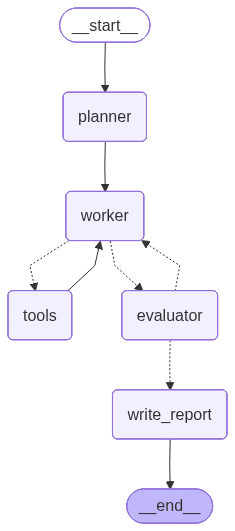

In [79]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
#invoking
messagess = [
    SystemMessage(content= 'You are a helpful assistant'),
    HumanMessage(content='Types of jobs which would be completely cease to exist after 2030' \
    'since the rise of AI and Agentic AI')
]

state = {

    "messages" : messagess,
    "plan" : None,
    "feedback" : None,
    "rework_required" : None,
    "report" : None,
    "max_retry" : 0
}

result = await graph.ainvoke(state)

Planners PLAN - plan=['Research current trends in AI and Agentic AI development.', 'Identify sectors most affected by automation and AI advancements.', 'List jobs that are vulnerable to AI replacement, focusing on repetitive and low-skill tasks.', 'Explore expert predictions and studies regarding future job markets and AI impact until 2030.', 'Analyze case studies of industries already experiencing job losses due to AI.', 'Compile a comprehensive list of specific job titles likely to cease to exist by 2030.', 'Investigate potential new job types that could emerge as AI evolves and replaces existing roles.']
Here's the report by the Worker - 
 content="# Final Report on AI Trends and Job Market Impact\n\n## 1. Current Trends in AI and Agentic AI Development\nResearch indicates that AI is rapidly evolving, with significant advancements in areas such as natural language processing, machine learning, and robotics. Agentic AI, capable of autonomous decision-making, is being integrated into 

In [55]:
print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>